In [1]:
# ==========================================
# Cell 1: Install / import dependencies
# ==========================================

from pathlib import Path
import sys

import matplotlib.pyplot as plt
from IPython.display import display

cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd if (cwd / 'main.py').exists() else cwd.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from config import DEFAULT_SEED, make_params
from initialization import initialize_model
from main import run_one_round
from utils import set_random_seed
from visualization import (
    plot_final_opinion_distribution,
    plot_network_and_homophily,
    plot_opinion_leaders,
    plot_time_series_summaries,
    prepare_graph_for_visualization,
)


In [2]:
# ==========================================
# Cell 2: Random seed and helper functions
# ==========================================

SEED = DEFAULT_SEED
rng = set_random_seed(SEED)
SEED


42

In [3]:
# ==========================================
# Cell 3: Define model parameters
# ==========================================

params = make_params({
    "tolerance_threshold": 0.00,

    # 1. 先让初始分布更宽
    "opinion_std": 0.5,

    # 2. 降低冻结
    "tau_env": 0.90,
    "max_confidence": 15.0,

    # 3. 增强 out 区的强化/反弹
    "omega_pC_out": 0.12,
    "omega_pT_out": 0.04,
    "omega_nT_out": 0.10,
    "omega_nC_out": 0.00,

    # 4. 增加曝光
    "p_O": 0.04,
    "beta2_diff": 1.00,
    "max_read_capacity": 12,

    # 5. 把你之前加的 warmup 放松
    "creation_warmup_rounds": 2,
    "stance_feedback_warmup_rounds": 4,
    "style_feedback_warmup_rounds": 4,
    "creation_warmup_floor": 0.80,
    "stance_feedback_floor": 0.70,
    "style_feedback_floor": 0.70,

    # 6. 让同温层重连更容易
    "theta_F": 2.8,
    "a4": 1.6,
    "b_O": 0.6,
    "b_TO": 1.0,
})


params


{'N': 1000,
 'm_BA': 3,
 'leader_in_degree_threshold': 15,
 'T_rounds': 50,
 'opinion_mean': 0.0,
 'opinion_std': 0.5,
 'Abar_low': 0.2,
 'Abar_high': 0.8,
 'rho_A': 0.6,
 'omega1': 0.1,
 'omega2': 0.2,
 'omega3': 0.05,
 'N_E': 10.0,
 'kappa': 2.0,
 'alpha0': -2.25,
 'alpha1': 1.8,
 'alpha2': 1.2,
 'alpha3': 0.25,
 'originator_prob_cap': 0.3,
 'alpha_B': 1.5,
 'beta1': 0.6,
 'beta2': 0.4,
 'beta3': 0.5,
 'beta4': 0.7,
 'c0': 0.55,
 'epsilon_std': 0.15,
 'epsilon_ambiguity': 0.5,
 'gamma0': 0.15,
 'gamma1': 0.55,
 'gamma2': 0.35,
 'gamma3': 0.45,
 'gamma4': 0.25,
 'c_C': 0.1,
 'eta_C_std': 0.12,
 'delta0': 0.05,
 'delta1': 0.55,
 'delta2': 0.45,
 'delta3': 0.4,
 'delta4': 0.3,
 'c_T': 0.18,
 'eta_T_std': 0.12,
 'p_O': 0.04,
 'beta0_diff': -3.2,
 'beta1_diff': 0.8,
 'beta2_diff': 1.0,
 'max_read_capacity': 12,
 'w_o': 1.0,
 'w_l': 1.5,
 'tolerance_threshold': 0.0,
 'tau_env': 0.9,
 'eta_expression': 1.0,
 'max_confidence': 15.0,
 'omega_pC_in': 0.05,
 'omega_pT_in': 0.01,
 'omega_nC_in':

In [4]:
# ==========================================
# Cell 4: Initialize BA network and agent states
# ==========================================

G, G_initial_undirected, agents, blocks, pos = initialize_model(params, seed=SEED)

print('Initialization finished.')
print(f"Nodes: {G.number_of_nodes()}")
print(f"Directed edges: {G.number_of_edges()}")
print(f"Opinion leaders: {agents['L'].sum()}")
agents.head()


Initialization finished.
Nodes: 1000
Directed edges: 2991
Opinion leaders: 16


,node,F_t,L,o_t,tau_t,tau_t1,confidence,s_t,Abar,A_t,m_t,O_t,C_t,M_pC_prev,M_pT_prev,M_nC_prev,M_nT_prev
0,0,25,1,0.750953,6.584833,6.584833,6.584833,1,0.680226,0.680226,0.905492,0,0,0.0,0.0,0.0,0.0
1,1,16,1,-0.688297,9.122560,9.122560,9.122560,-1,0.494966,0.494966,-0.880186,0,0,0.0,0.0,0.0,0.0
2,2,2,0,0.400360,2.395038,2.395038,2.395038,1,0.344905,0.344905,0.664439,0,0,0.0,0.0,0.0,0.0
3,3,22,1,0.703094,9.195984,9.195984,9.195984,1,0.409176,0.409176,0.886682,0,0,0.0,0.0,0.0,0.0
4,4,46,1,-0.735825,8.322909,8.322909,8.322909,-1,0.637545,0.637545,-0.899892,0,0,0.0,0.0,0.0,0.0


In [5]:
# ==========================================
# Cell 5: Define one-round simulation function
# ==========================================

# The one-round workflow now lives in the local project code
# so that the notebook and scripts share the same implementation.
run_one_round


<function main.run_one_round(graph, agents, blocks: 'dict', params: 'dict', rng, current_round: 'int' = 1)>

In [6]:
# ==========================================
# Cell 6: Run the simulation for multiple rounds
# ==========================================

round_records = []
all_posts_by_round = {}
all_exposure_sets_by_round = {}

for t in range(1, params['T_rounds'] + 1):
    # 注意这里必须显式加上 current_round=t
    G, agents, posts, exposure_sets, summary = run_one_round(G, agents, blocks, params, rng, current_round=t)
    summary['round'] = t
    round_records.append(summary)
    all_posts_by_round[t] = posts
    all_exposure_sets_by_round[t] = exposure_sets
    print(
        f"Round {t:02d} | "
        f"Creators={summary['actual_creators']:3d} | "
        f"Support={summary['support_posts']:3d} | "
        f"Oppose={summary['oppose_posts']:3d} | "
        f"Toxic={summary['toxic_posts']:3d} | "
        f"AvgExposure={summary['avg_exposure_size']:.2f} | "
        f"Edges={summary['edge_count']}"
    )

import pandas as pd
history_df = pd.DataFrame(round_records)
history_df

Round 01 | Creators=138 | Support= 60 | Oppose= 78 | Toxic= 68 | AvgExposure=8.40 | Edges=3060
Round 02 | Creators=184 | Support= 98 | Oppose= 86 | Toxic=147 | AvgExposure=8.73 | Edges=3025
Round 03 | Creators=161 | Support= 76 | Oppose= 85 | Toxic=135 | AvgExposure=7.94 | Edges=2983
Round 04 | Creators=131 | Support= 59 | Oppose= 72 | Toxic=118 | AvgExposure=8.89 | Edges=2971
Round 05 | Creators=111 | Support= 55 | Oppose= 56 | Toxic=105 | AvgExposure=7.57 | Edges=2954
Round 06 | Creators=103 | Support= 52 | Oppose= 51 | Toxic= 94 | AvgExposure=8.36 | Edges=2994
Round 07 | Creators= 78 | Support= 37 | Oppose= 41 | Toxic= 68 | AvgExposure=5.51 | Edges=3015
Round 08 | Creators=103 | Support= 54 | Oppose= 49 | Toxic= 88 | AvgExposure=8.29 | Edges=2962
Round 09 | Creators=122 | Support= 57 | Oppose= 65 | Toxic=115 | AvgExposure=8.59 | Edges=2924
Round 10 | Creators= 92 | Support= 49 | Oppose= 43 | Toxic= 88 | AvgExposure=8.38 | Edges=2862
Round 11 | Creators= 46 | Support= 22 | Oppose= 24

,potential_originators,actual_creators,constructive_posts,toxic_posts,support_posts,oppose_posts,avg_exposure_size,mean_opinion,std_opinion,opinion_variance,extremist_ratio,homophily_ratio,sign_modularity,edge_count,round
0,257,138,70,68,60,78,8.403,0.002368,0.504474,0.254239,0.203,0.496078,-0.004158,3060,1
1,296,184,37,147,98,86,8.732,0.003176,0.523787,0.274079,0.226,0.497190,-0.003660,3025,2
2,310,161,26,135,76,85,7.939,-0.001807,0.541048,0.292441,0.237,0.506537,0.004944,2983,3
3,287,131,13,118,59,72,8.889,-0.001470,0.563041,0.316699,0.269,0.522720,0.021122,2971,4
4,294,111,6,105,55,56,7.571,-0.003147,0.581357,0.337638,0.292,0.528436,0.026998,2954,5
5,282,103,9,94,52,51,8.360,-0.000948,0.596597,0.355571,0.316,0.533400,0.031893,2994,6
6,292,78,10,68,37,41,5.514,-0.002786,0.611879,0.374022,0.340,0.540962,0.039228,3015,7
7,292,103,15,88,54,49,8.293,-0.002651,0.632417,0.399551,0.372,0.545915,0.043991,2962,8
8,309,122,7,115,57,65,8.588,0.000193,0.644068,0.414408,0.388,0.543434,0.043733,2924,9
9,294,92,4,88,49,43,8.380,0.008808,0.658746,0.433512,0.421,0.541579,0.041335,2862,10


In [7]:
# ==========================================
# Cell 7: Show round-by-round summary
# ==========================================

display(history_df)


,potential_originators,actual_creators,constructive_posts,toxic_posts,support_posts,oppose_posts,avg_exposure_size,mean_opinion,std_opinion,opinion_variance,extremist_ratio,homophily_ratio,sign_modularity,edge_count,round
0,257,138,70,68,60,78,8.403,0.002368,0.504474,0.254239,0.203,0.496078,-0.004158,3060,1
1,296,184,37,147,98,86,8.732,0.003176,0.523787,0.274079,0.226,0.497190,-0.003660,3025,2
2,310,161,26,135,76,85,7.939,-0.001807,0.541048,0.292441,0.237,0.506537,0.004944,2983,3
3,287,131,13,118,59,72,8.889,-0.001470,0.563041,0.316699,0.269,0.522720,0.021122,2971,4
4,294,111,6,105,55,56,7.571,-0.003147,0.581357,0.337638,0.292,0.528436,0.026998,2954,5
5,282,103,9,94,52,51,8.360,-0.000948,0.596597,0.355571,0.316,0.533400,0.031893,2994,6
6,292,78,10,68,37,41,5.514,-0.002786,0.611879,0.374022,0.340,0.540962,0.039228,3015,7
7,292,103,15,88,54,49,8.293,-0.002651,0.632417,0.399551,0.372,0.545915,0.043991,2962,8
8,309,122,7,115,57,65,8.588,0.000193,0.644068,0.414408,0.388,0.543434,0.043733,2924,9
9,294,92,4,88,49,43,8.380,0.008808,0.658746,0.433512,0.421,0.541579,0.041335,2862,10


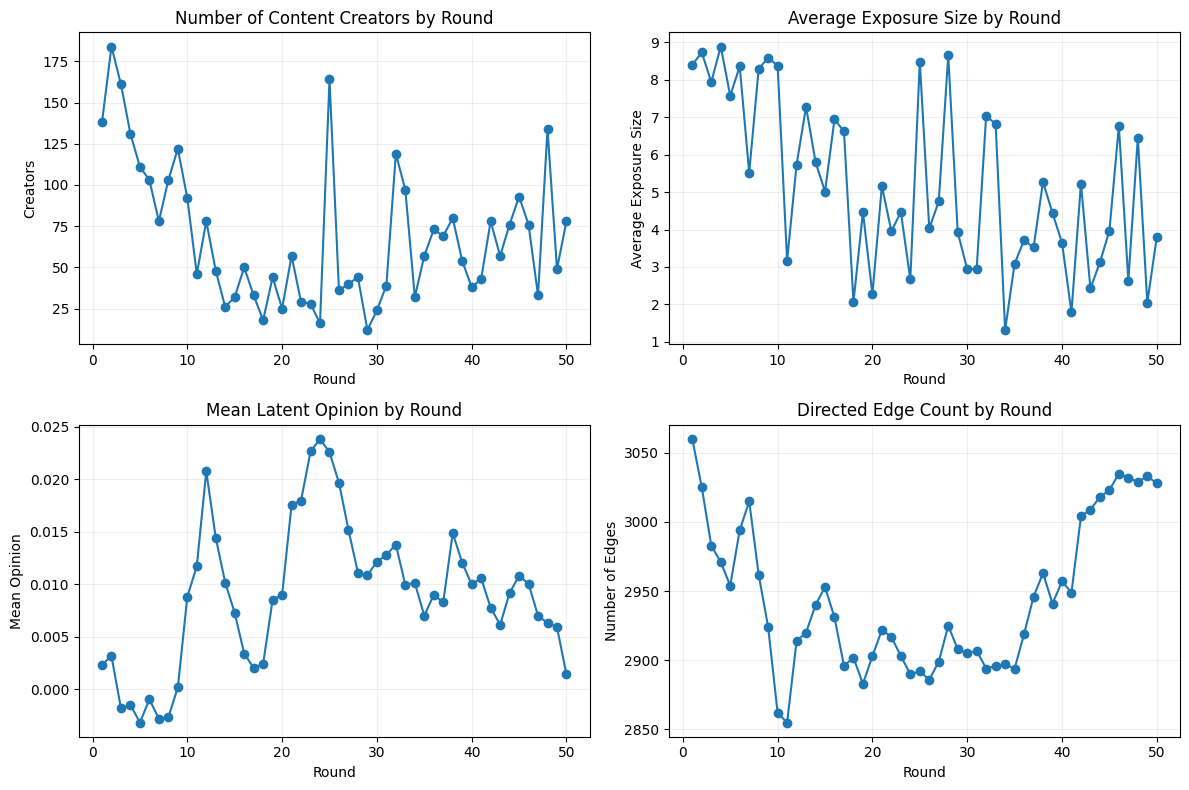

In [8]:
# ==========================================
# Cell 8: Plot time-series summaries over rounds
# ==========================================

fig, _ = plot_time_series_summaries(history_df)
plt.show()


In [9]:
# ==========================================
# Cell 9: Prepare final-round graph for visualization
# ==========================================

G_updated = prepare_graph_for_visualization(G, agents)
final_posts = all_posts_by_round[params['T_rounds']]
final_exposure_sets = all_exposure_sets_by_round[params['T_rounds']]

print('Final round prepared for visualization.')
print(f"Final number of edges: {G_updated.number_of_edges()}")


Final round prepared for visualization.
Final number of edges: 3028


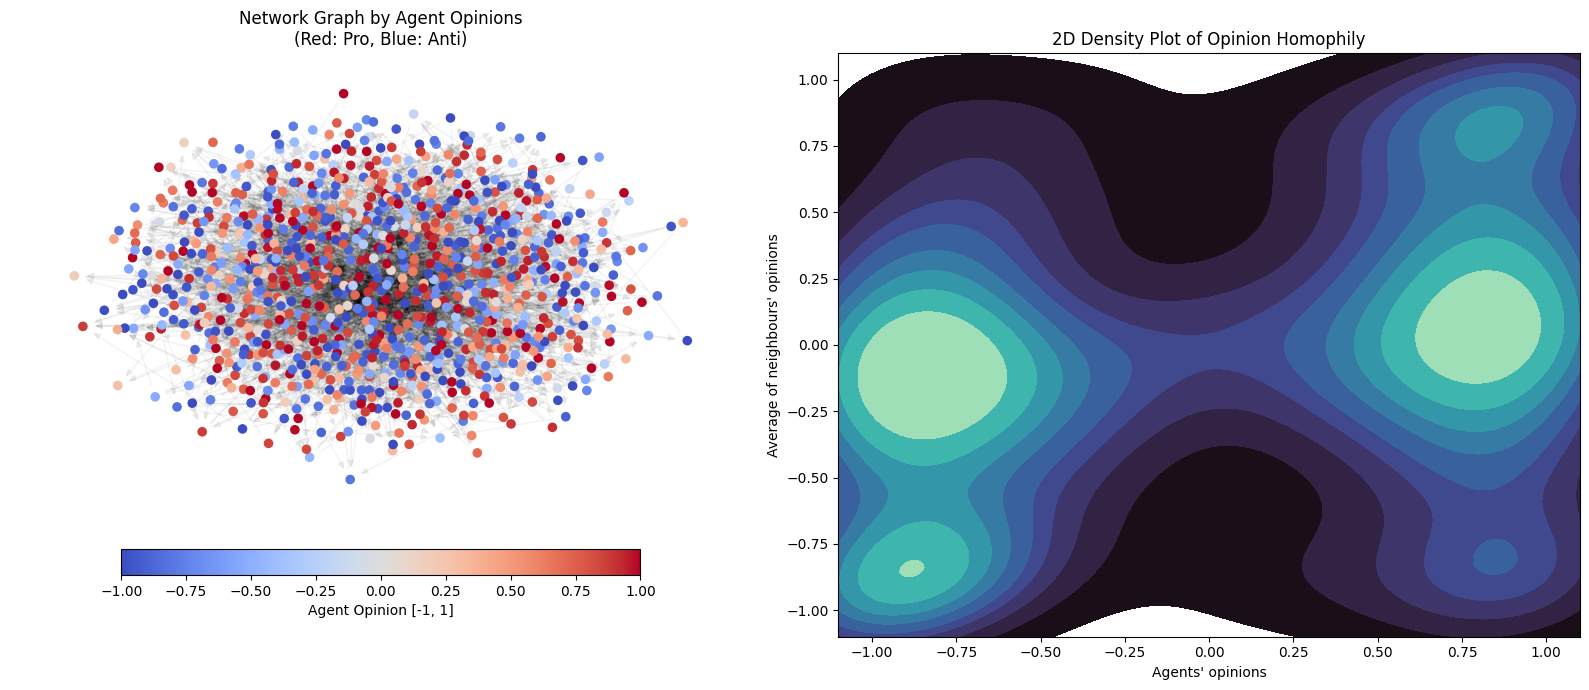

In [10]:
# ==========================================
# Cell 10: 1x2 visualization
# ==========================================

fig, _ = plot_network_and_homophily(G_updated, pos)
plt.show()


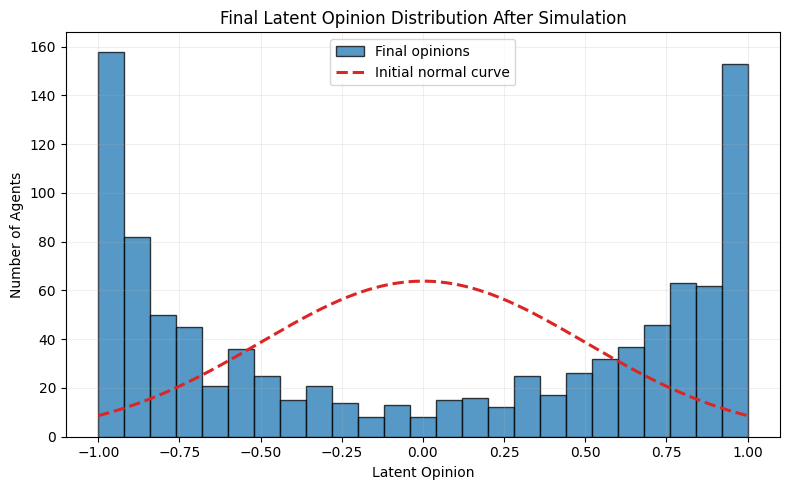

In [11]:
# ==========================================
# Cell 11: Final opinion distribution
# ==========================================

fig, _ = plot_final_opinion_distribution(agents, params=params)
plt.show()


/Users/paimon/projects/Opinion_ABM/visualization.py:162: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.tight_layout()
/Users/paimon/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


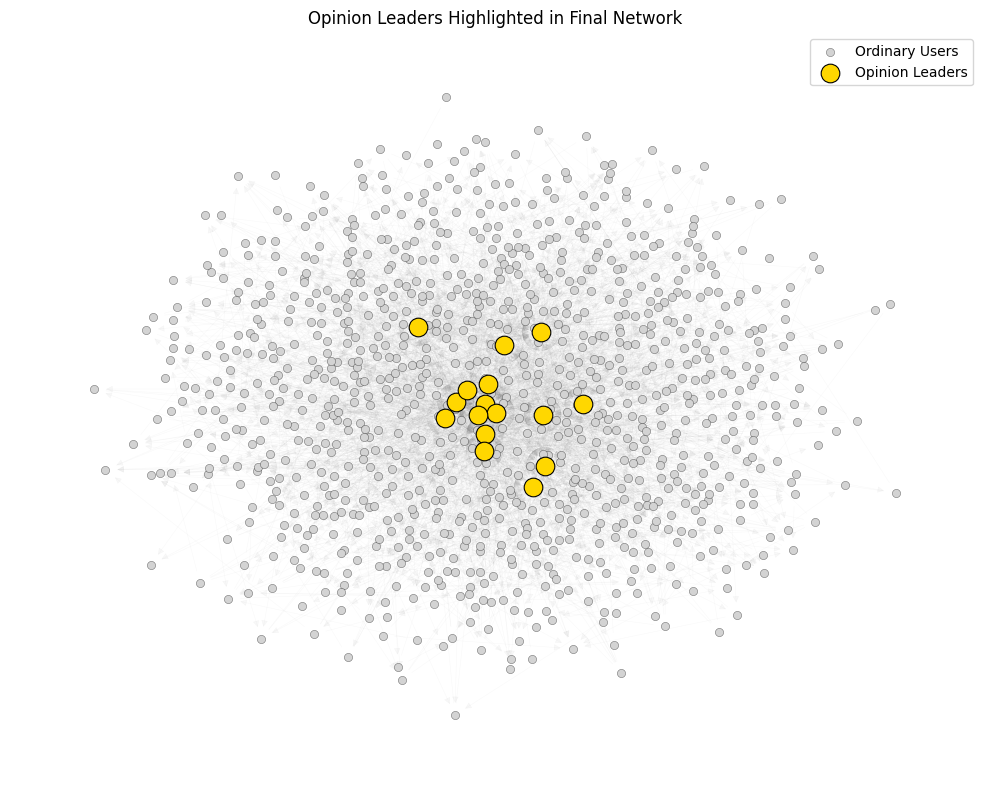

In [12]:
# ==========================================
# Cell 12: Highlight opinion leaders
# ==========================================

fig, _ = plot_opinion_leaders(G_updated, agents, pos)
plt.show()
